# 03 — MGTAB Graph EDA

Khám phá cấu trúc graph: degree, density, connected components, reciprocity và phân phối quan hệ. Graph được phân tích ở hai dạng: directed theo `edge_index` gốc và undirected baseline cho PYMK.

In [1]:
# Nhập thư viện cho thống kê graph, sparse matrix và trực quan hóa.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse
from scipy.sparse.csgraph import connected_components

In [2]:
# Nạp raw graph và chuyển edge, weight sang numpy để phân tích nhanh.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "MGTAB"

def load_tensor(name):
    try:
        return torch.load(DATA_DIR / name, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(DATA_DIR / name, map_location="cpu")

edge_index = load_tensor("edge_index.pt").long()
edge_type = load_tensor("edge_type.pt").long()
edge_weight = load_tensor("edge_weight.pt").float()
num_nodes = int(load_tensor("features.pt").shape[0])
src = edge_index[0].numpy()
dst = edge_index[1].numpy()
types = edge_type.numpy()
weights = edge_weight.numpy()
num_edges = len(src)
print(f"nodes={num_nodes:,}, directed edge rows={num_edges:,}")

nodes=10,199, directed edge rows=1,700,108


## 1. Kích thước và mật độ graph

In [3]:
# Tính edge unique, số pair undirected và density của graph.
directed_keys = src.astype(np.int64) * num_nodes + dst.astype(np.int64)
reverse_keys = dst.astype(np.int64) * num_nodes + src.astype(np.int64)
unique_directed_edges = np.unique(directed_keys)
undirected_keys = np.minimum(src, dst).astype(np.int64) * num_nodes + np.maximum(src, dst).astype(np.int64)
unique_undirected_edges = np.unique(undirected_keys)

possible_directed = num_nodes * (num_nodes - 1)
possible_undirected = num_nodes * (num_nodes - 1) // 2
basic_report = pd.DataFrame({
    "metric": [
        "nodes", "edge rows", "unique directed edges",
        "unique undirected pairs", "directed density", "undirected density",
    ],
    "value": [
        num_nodes, num_edges, len(unique_directed_edges), len(unique_undirected_edges),
        len(unique_directed_edges) / possible_directed,
        len(unique_undirected_edges) / possible_undirected,
    ],
})
basic_report

,metric,value
0,nodes,1.019900e+04
1,edge rows,1.700108e+06
2,unique directed edges,1.138182e+06
3,unique undirected pairs,9.084600e+05
4,directed density,1.094307e-02
5,undirected density,1.746881e-02


## 2. Degree distribution

In [4]:
# Tính in-degree, out-degree và các thống kê degree của node.
out_degree = np.bincount(src, minlength=num_nodes)
in_degree = np.bincount(dst, minlength=num_nodes)
undirected_degree = np.bincount(
    np.concatenate([src, dst]), minlength=num_nodes
)

def describe(values, name):
    return {
        "degree": name,
        "min": int(values.min()),
        "p25": float(np.percentile(values, 25)),
        "median": float(np.median(values)),
        "p75": float(np.percentile(values, 75)),
        "p90": float(np.percentile(values, 90)),
        "p95": float(np.percentile(values, 95)),
        "p99": float(np.percentile(values, 99)),
        "max": int(values.max()),
        "zero_count": int((values == 0).sum()),
    }

degree_report = pd.DataFrame([
    describe(in_degree, "in-degree"),
    describe(out_degree, "out-degree"),
    describe(undirected_degree, "undirected degree"),
])
degree_report

,degree,min,p25,median,p75,p90,p95,p99,max,zero_count
0,in-degree,0,29.0,66.0,155.0,399.2,655.1,1459.04,8330,172
1,out-degree,0,40.0,83.0,178.0,418.2,646.0,1143.34,8383,59
2,undirected degree,0,86.0,153.0,314.0,836.0,1324.1,2518.34,16713,52


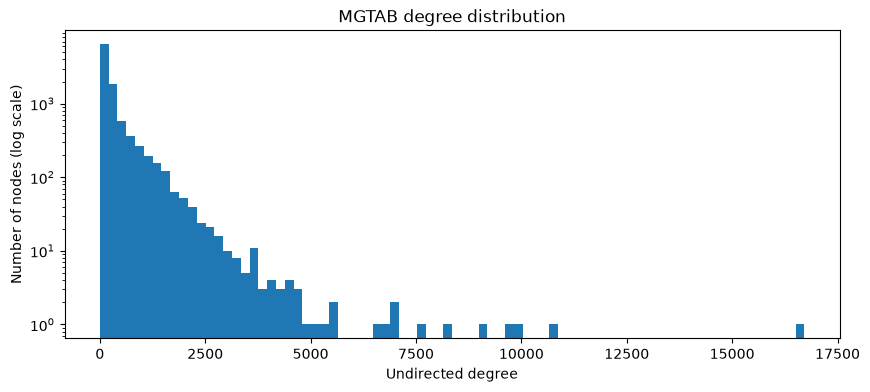

In [5]:
# Vẽ histogram degree để quan sát hub và độ lệch của phân phối.
plt.figure(figsize=(10, 4))
plt.hist(undirected_degree, bins=80, log=True)
plt.xlabel("Undirected degree")
plt.ylabel("Number of nodes (log scale)")
plt.title("MGTAB degree distribution")
plt.show()

## 3. Connected components và reciprocity

In [6]:
# Tạo adjacency undirected, tính connected components và reciprocity.
adj_undirected = sparse.coo_matrix(
    (np.ones(len(undirected_keys), dtype=np.int8), (src, dst)),
    shape=(num_nodes, num_nodes),
).tocsr()
adj_undirected = adj_undirected.maximum(adj_undirected.T)
n_components, component_ids = connected_components(adj_undirected, directed=False)
component_sizes = np.bincount(component_ids, minlength=n_components)
largest_size = int(component_sizes.max())

sorted_component_sizes = np.sort(component_sizes)[::-1]
component_report = pd.DataFrame({
    "metric": ["components", "largest component", "largest component share", "isolated nodes"],
    "value": [n_components, largest_size, largest_size / num_nodes, int((component_sizes == 1).sum())],
})
print(component_report)
print("Largest component sizes:", sorted_component_sizes[:10].tolist())

reverse_exists = np.isin(reverse_keys, directed_keys)
reciprocity = float(reverse_exists.mean())
print(f"Directed reciprocity: {reciprocity:.4f}")

                    metric         value
0               components     55.000000
1        largest component  10145.000000
2  largest component share      0.994705
3           isolated nodes     54.000000
Largest component sizes: [10145, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Directed reciprocity: 0.5547


In [7]:
# Tổng hợp số edge, tỷ lệ và unique pair theo từng relation.
RELATION_NAMES = {0: "followers", 1: "friends", 2: "mention", 3: "reply", 4: "quoted", 5: "url", 6: "hashtag"}
relation_rows = []
for relation_id in np.unique(types):
    mask = types == relation_id
    relation_rows.append({
        "relation_id": int(relation_id),
        "relation": RELATION_NAMES.get(int(relation_id), "unknown"),
        "edge_rows": int(mask.sum()),
        "share": float(mask.mean()),
        "mean_weight": float(weights[mask].mean()),
        "unique_pairs": int(np.unique(directed_keys[mask]).size),
    })
relation_report = pd.DataFrame(relation_rows).sort_values("edge_rows", ascending=False)
relation_report

,relation_id,relation,edge_rows,share,mean_weight,unique_pairs
1,1,friends,412575,0.242676,1.000000,412575
0,0,followers,308120,0.181236,1.000000,308120
6,6,hashtag,300000,0.176459,0.535218,300000
5,5,url,263800,0.155167,0.400206,263800
3,3,reply,223466,0.131442,1.000000,26380
2,2,mention,114516,0.067358,1.000000,114516
4,4,quoted,77631,0.045662,1.000000,23269
